In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import xesmf as xe                     # package for regridding 
#import cartopy.crs as ccrs              # for the regridding test(now only to understand how it works later maybe more - probably I can do a lot with this package

#import gravity toolkit 
import gravity_toolkit as gravtk

#from scipy import signal              #not sure if I need those
#import importlib

import Kyrafunctions as ky

import sys
sys.path.append('../code')


import SeaLevelContrib as slc


In [39]:
data_path = '../data/GravIs/'
output_path = '../outputs/Antarcticatest/'
output_path2 = '../outputs/Gravis_Antarctica/'

<xarray.Dataset> Size: 4MB
Dimensions:   (time: 240, y: 55, x: 36)
Coordinates:
  * x         (x) float64 288B -8e+05 -7.5e+05 -7e+05 ... 8.5e+05 9e+05 9.5e+05
  * y         (y) float64 440B -3.4e+06 -3.35e+06 -3.3e+06 ... -7.5e+05 -7e+05
  * time      (time) datetime64[ns] 2kB 2002-04-18 ... 2024-12-16T12:00:00
Data variables:
    time_dec  (time) float64 2kB ...
    lon       (y, x) float64 16kB ...
    lat       (y, x) float64 16kB ...
    dm        (time, y, x) float64 4MB ...
    area      (y, x) float64 16kB ...
    crs       |S1 1B ...
Attributes: (12/16)
    title:                Gridded GIS Mass Changes
    institution:          TU Dresden, Chair of Geodetic Earth System Research
    authors:              Andreas Groh, Martin Horwath, Thorben Döhne
    project:              GravIS GRACE/GRACE-FO Level-3 Products
    source:               Monthly COST-G RL01 GRACE/GRACE-FO Level-2B product...
    summary:              GRACE/GRACE-FO derived time series of gridded Green...
    ...                   ...
    product_version:      0003
    doi:                  10.5880/COST-G.GRAVIS_01_L3_ICE
    netCDF_version:       netCDF-4_classic
    conventions:          CF-1.6
    date_created:         2025-04-07
    contact:              thorben.doehne@tu-dresden.de

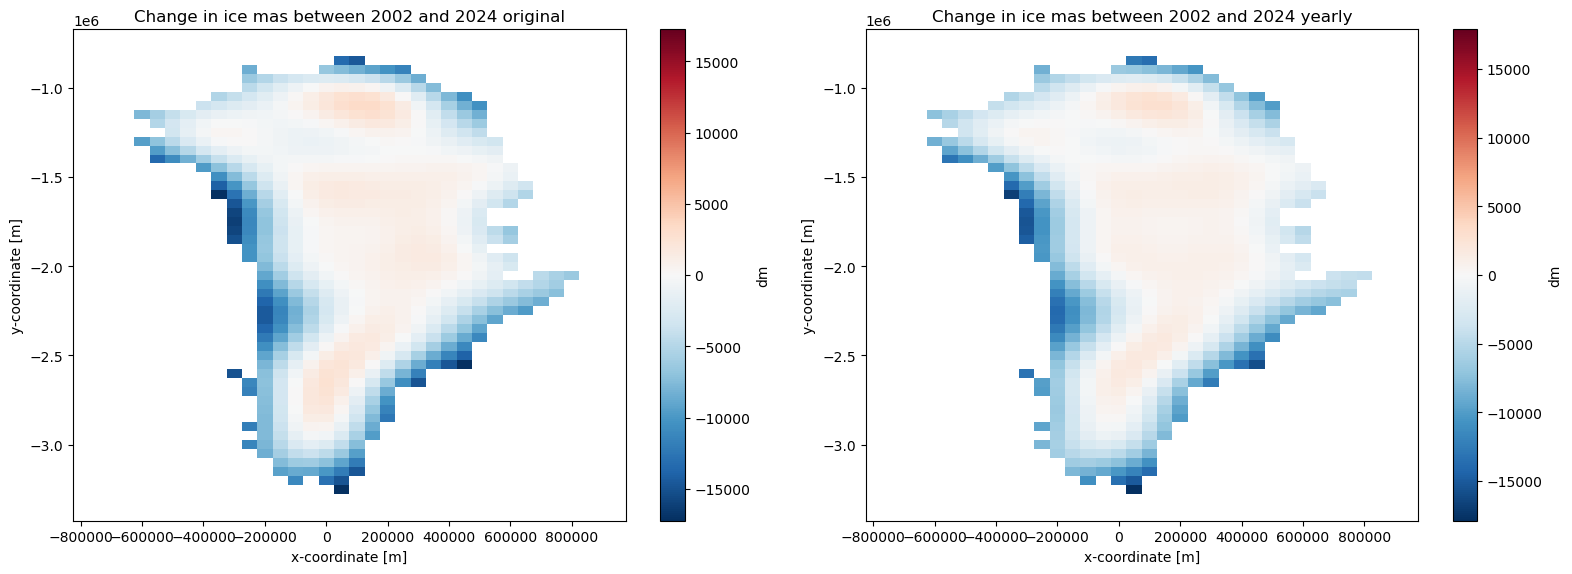

max_y
2930.3476190476194
max_orig
3306.7
min_y
-17883.584523809524
min_orig
-17232.5
Number of non-NaNs in dm_y: 16652


<xarray.Dataset> Size: 413kB
Dimensions:   (y: 55, x: 36, time: 23)
Coordinates:
  * x         (x) float64 288B -8e+05 -7.5e+05 -7e+05 ... 8.5e+05 9e+05 9.5e+05
  * y         (y) float64 440B -3.4e+06 -3.35e+06 -3.3e+06 ... -7.5e+05 -7e+05
  * time      (time) datetime64[ns] 184B 2002-12-31 2003-12-31 ... 2024-12-31
Data variables:
    lon       (y, x) float64 16kB ...
    lat       (y, x) float64 16kB ...
    area      (y, x) float64 16kB ...
    crs       |S1 1B ...
    dm        (time, y, x) float64 364kB nan nan nan nan nan ... nan nan nan nan
    time_dec  (time) int64 184B 2002 2003 2004 2005 2006 ... 2021 2022 2023 2024
Attributes: (12/16)
    title:                Gridded GIS Mass Changes
    institution:          TU Dresden, Chair of Geodetic Earth System Research
    authors:              Andreas Groh, Martin Horwath, Thorben Döhne
    project:              GravIS GRACE/GRACE-FO Level-3 Products
    source:               Monthly COST-G RL01 GRACE/GRACE-FO Level-2B product...
    summary:              GRACE/GRACE-FO derived time series of gridded Green...
    ...                   ...
    product_version:      0003
    doi:                  10.5880/COST-G.GRAVIS_01_L3_ICE
    netCDF_version:       netCDF-4_classic
    conventions:          CF-1.6
    date_created:         2025-04-07
    contact:              thorben.doehne@tu-dresden.de

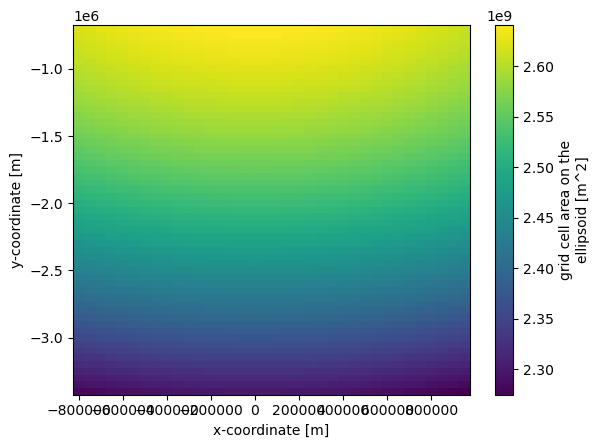

In [42]:
#Open the COST-G and GFZ dataset to compare 
gre = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_GIS_GRID_TUD_0003.nc")

display(gre)

# Drop dm, time_dec, and the old time coordinate: this is everything that dempends on time
gre_y = gre.drop_vars(['dm', 'time_dec', 'time'], errors='ignore')

# Resample dm to yearly
dm_y = gre['dm'].resample(time='1Y').mean(keep_attrs=True)

# Ensure correct order
dm_y = dm_y.transpose('time', 'y', 'x')

# Assign dm back
gre_y = gre_y.assign({'dm': dm_y})

# Assign the time coordinate from dm_y (now no conflicts)
gre_y = gre_y.assign_coords(time=dm_y['time'])


# Compute decimal year as a NumPy array
time_dec = gre_y["time"].dt.year 

# Add it as a new variable (not just a coordinate)
gre_y["time_dec"] = ("time", time_dec.data)

# Add metadata (optional but good practice)
gre_y["time_dec"].attrs = {
    "long_name": "Decimal year",
    "units": "year"
}



# plot the two difference figures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

(gre['dm'].isel(time=-1)- gre['dm'].isel(time=0)).plot(ax=ax1, cmap='RdBu_r')
ax1.set_title('Change in ice mas between 2002 and 2024 original')

(gre_y['dm'].isel(time=-1) - gre_y['dm'].isel(time=0)).plot(ax=ax2, cmap='RdBu_r')
ax2.set_title('Change in ice mas between 2002 and 2024 yearly')
plt.tight_layout()
plt.show()
max_y = (gre_y['dm'].isel(time=-1) - gre_y['dm'].isel(time=0)).max()
print('max_y')
print(max_y.values)
max_orig = (gre['dm'].isel(time=-1) - gre['dm'].isel(time=0)).max()
print('max_orig')
print(max_orig.values)


min_y = (gre_y['dm'].isel(time=-1) - gre_y['dm'].isel(time=0)).min()
print('min_y')
print(min_y.values)
min_orig = (gre['dm'].isel(time=-1) - gre['dm'].isel(time=0)).min()
print('min_orig')
print(min_orig.values)



# Check number of non-NaNs
print("Number of non-NaNs in dm_y:", dm_y.count().values)
      
display(gre_y)

gre['area'].plot()


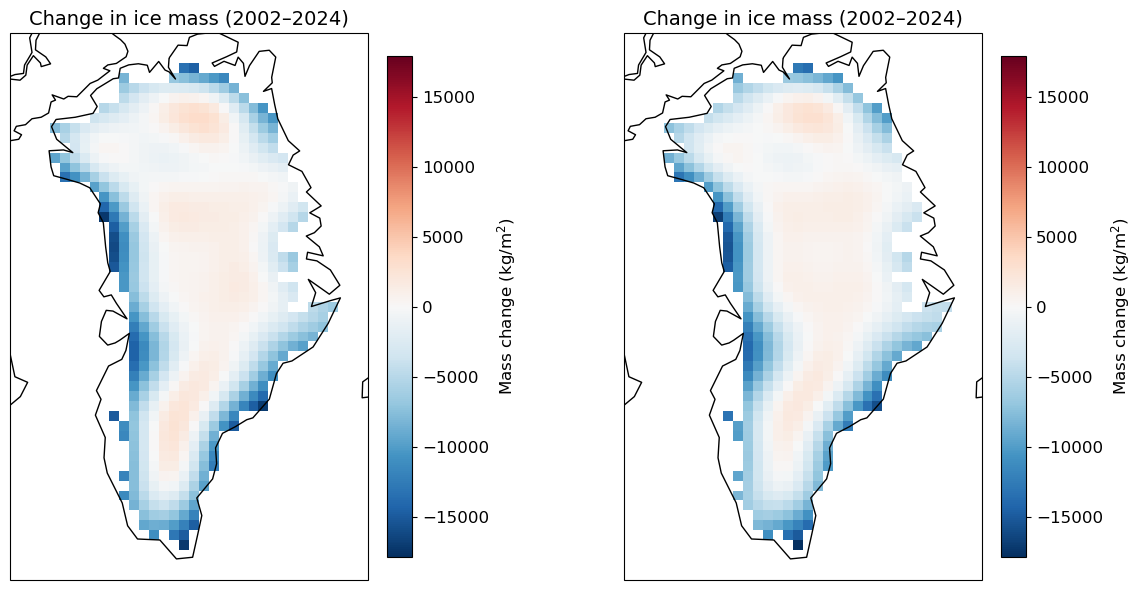

In [41]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Compute total changes
change_orig = gre['dm'].isel(time=-1) - gre['dm'].isel(time=0)
change_year = gre_y['dm'].isel(time=-1) - gre_y['dm'].isel(time=0)

# Projection
proj = ccrs.Stereographic(central_latitude=90, central_longitude=-45, true_scale_latitude=70)

# --- Determine symmetric color scale around zero ---
vmax = np.max(np.abs([change_orig.max(), change_orig.min(),
                      change_year.max(), change_year.min()]))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6), subplot_kw={'projection': proj})

for ax, data, title in zip([ax1, ax2], [change_orig, change_year], ["Original", "Yearly"]):
    pc = ax.pcolormesh(
        gre['x'], gre['y'], data,
        transform=proj, cmap='RdBu_r',
        vmin=-vmax, vmax=vmax, shading='auto'
    )
    ax.coastlines(resolution='110m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(f"Change in ice mass (2002–2024)", fontsize=14)# – {title}")
    #plt.colorbar(pc, ax=ax, orientation='vertical', pad=0.03, aspect=40, label="Mass change (kg/m^2)")
    cbar = plt.colorbar(
    pc, ax=ax, orientation='vertical',
    pad=0.03, 
    fraction=0.0385
    )
    cbar.set_label("Mass change (kg/m$^2$)", fontsize=12)
    # Change the tick numbers size
    cbar.ax.tick_params(labelsize=12)



    

plt.tight_layout()
plt.show()



2002-04-18T00:00:00.000000000 2024-12-16T12:00:00.000000000
Average mass loss rate (COST-G): -227.54 Gt/yr
TOTAL MASS LOSS BETWEEN 2002 AND 2024:-4629164231601924.00 kg


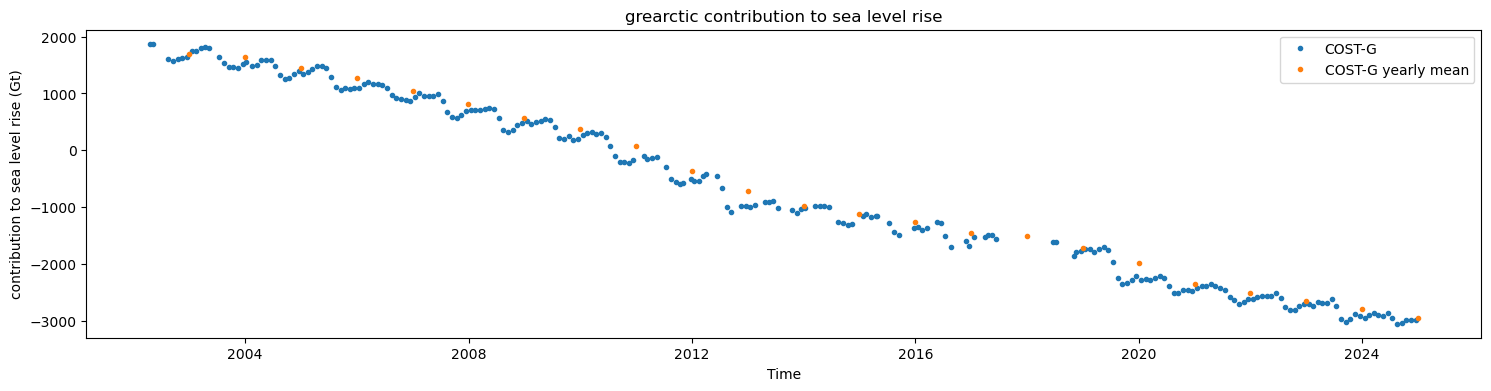

In [5]:

# Create dataset with total mass loss over Antarctica for the 2 datasets. 

gresum = (gre['dm']*gre['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)  # Multiply the dm (kg per square meter ice loss) with the area to ge total ice loss, then sum over all cells to get total mass loss and translate to Gt

# Represent values relative to the value at t=0
gresum_rel = gresum - gresum.isel(time=0)



#print(gravis_data['time [yyyy-mm-dd]'].min(), gravis_data['time [yyyy-mm-dd]'].max())
print(gresum_rel['time'].min().values, gresum_rel['time'].max().values)


#Determine the trend - CHECK THIS CODE
# Make numeric array of years plus fractin of the days. 
time_years = gresum['time'].dt.year + gresum['time'].dt.dayofyear / 365.25

# Linear trend (slope = Gt/yr)
slope1, intercept1 = np.polyfit(time_years, gresum_rel, 1)

print(f"Average mass loss rate (COST-G): {slope1:.2f} Gt/yr")



# Check total mass loss between 2002 and now based on gre_y

gresumyear = (gre_y['dm']*gre['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12) 

totalmassgre = (gresumyear.isel(time=-1) - gresumyear.isel(time=0))*1e12    #from gt back to kg
print(f"TOTAL MASS LOSS BETWEEN 2002 AND 2024:{totalmassgre:.2f} kg")




#Make a figure 
plt.figure(figsize=(18,4)) 


#plt.plot(gravis_data['time [yyyy-mm-dd]'], Gravistest, label='GRAVIS_directly', color='black', linestyle='-', marker='')

#gresum_rel.plot(marker='.', linestyle='', label='COST-G') #multiply gresum by 1.2 to line up with the black line.. .that is weird 
#(gresumyear - gresumyear.isel(time=0) ).plot(label='Cost-G yearly average')
gresum.plot(marker='.', linestyle='', label='COST-G') 
gresumyear.plot(marker='.', linestyle='', label='COST-G yearly mean') 


plt.xlabel("Time")
plt.ylabel("contribution to sea level rise (Gt)")
plt.title("grearctic contribution to sea level rise")
plt.legend()
plt.show()



## Try to calculate the total mass loss grearctica

In [6]:
#check times
#time_list = gresum["time"].dt.strftime("%Y-%m-%d").values
#print(time_list)
#print(gresum['dm'].values)
# gresum is your 1D DataArray: sum over all coordinates per timestep
#gresum_interp = gresum.interpolate_na(dim="time", method="linear")
#gresum_interp.plot(marker='.', linestyle='', figsize=(12,4))



## Regridding to use GRD in the proper grid (lon, lat grid) 

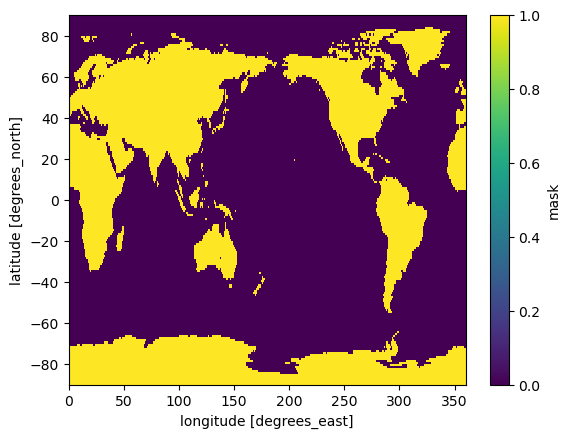

In [7]:
# Define the reference mask: 

path_masks = '/Users/kyrab/Github/SLBudget/data/Masks/'
masks_ds = xr.open_dataset(f'{path_masks}reference_masks.nc')

landsea = xr.where(masks_ds.mask==1, 0, 1)
landsea.plot()
#print(masks_ds['lat'].values)

#landsea


In [8]:
print(np.isnan(gre['dm']).mean().item())     # fraction NaN before resampling
print(np.isnan(gre_y['dm']).mean().item())   # fraction NaN after resampling

0.6343434343434343
0.6343434343434343


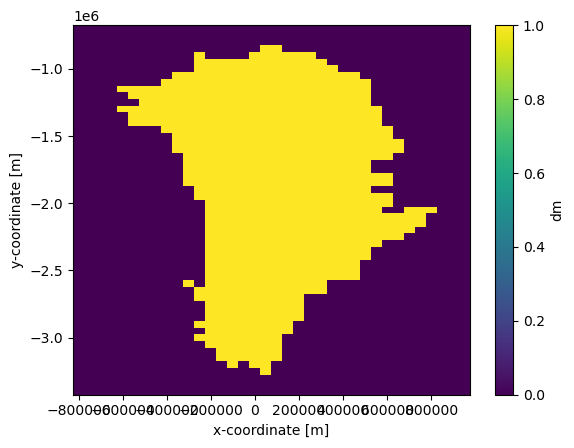

In [9]:
Agre = gre
Agre_y = gre_y


maskje1 = xr.where(np.isnan((Agre_y['dm'].isel(time=-1) - Agre_y['dm'].isel(time=0))), 0, 1)
#maskje1 = xr.where(np.isnan(Agre_y['dm'].isel(time=0)), 0, 1)
maskje1.plot()
areabeforeregridding = (Agre_y['area']*maskje1).sum(dim=['x', 'y'], skipna=True)



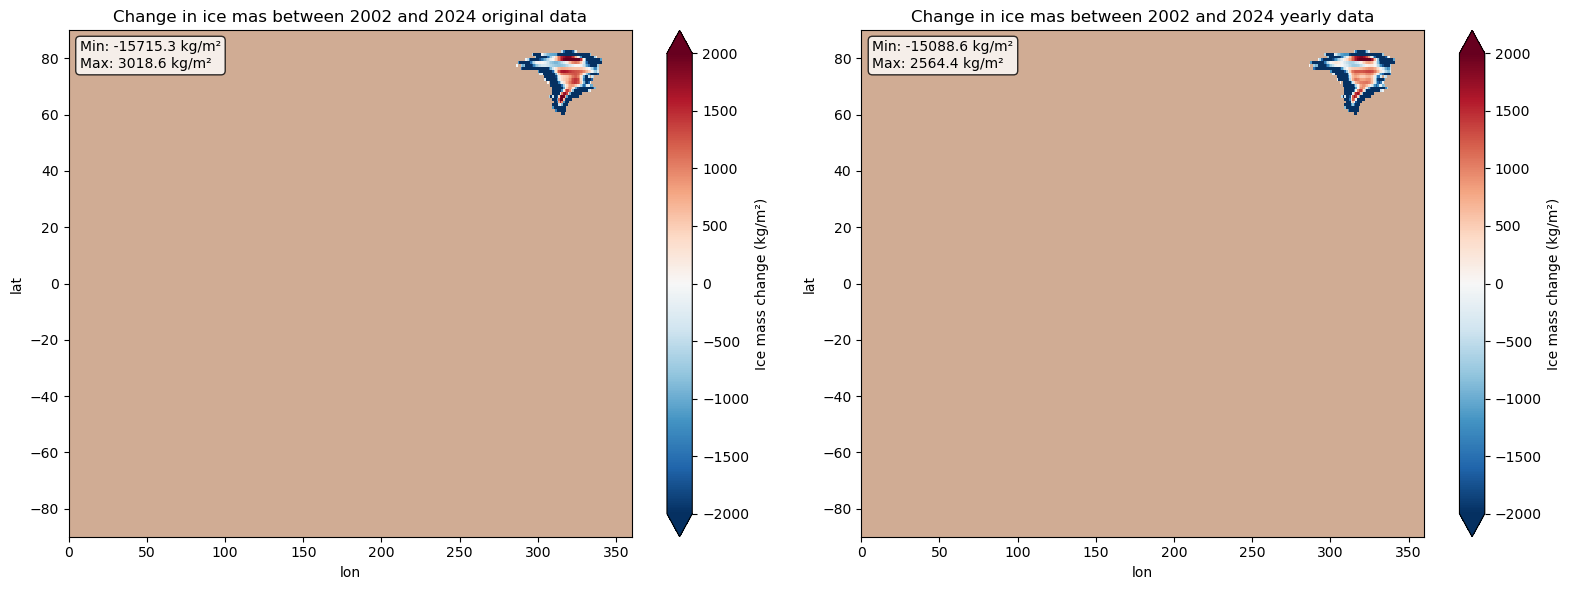

In [10]:
# Regridding 

#define resolution reference grid (needs to have the same dimensions as the mask
#lon_res = 1
#lat_res = 1

#lon_target = np.arange(0, 360 , lon_res)
#lat_target = np.arange(-90, 90 , lat_res)  # (this should be until 90+lat_res otherwise you miss one pole??


# Or use the lon and lat values from the mask directly: Here, points are defined between 2 degrees. It contains for lat all values 89.5 - N*1 with N in N
lon_target = masks_ds['lon'].values
lat_target = masks_ds['lat'].values 


lon2d, lat2d = np.meshgrid(lon_target, lat_target)   #creates lon lat pairs


# CHECK WHY THIS IS EXactly 
ds_out = xr.Dataset(
    {
        "lat": (["lat", "lon"], lat2d),
        "lon": (["lat", "lon"], lon2d)
    }
)



# First make sure nans are filled with zeros. Do that before regridding in stead of after. Otherwise areas with nans will not be regridded and the total area will be too small 
gre['dm'] = gre['dm'].fillna(0)
gre_y['dm'] = gre_y['dm'].fillna(0)
#print(gre['dm'].min().values)

#(gre_y['dm'].isel(time=-1) - gre_y['dm'].isel(time=0)).plot(cmap='RdBu_r')
#plt.show()

# Create the regridder. Array dataset containin lat lon values. 
regridder1 = xe.Regridder(gre, ds_out, "bilinear", periodic=False, reuse_weights=False, unmapped_to_nan=True)
regridder = xe.Regridder(gre_y, ds_out, "bilinear", periodic=False, reuse_weights=False, unmapped_to_nan=True)  # Periodic true does not work for some reason in this region... you need apparently full latitude coverage


# Regrid dm to lon-lat grid
dm_lonlat1 = regridder1(gre["dm"], keep_attrs=True)
dm_lonlat = regridder(gre_y["dm"], keep_attrs=True)
# Optional: Regrid area too if you need to recompute total mass
#area_lonlat = regridder(gre_y["area"], keep_attrs=True)


# Replace NANs with zeros: then there will be no mass change at areas that are not defined in the gre map - with this the area that was not defined in the original map is also filled with zeros
dm_lonlat_zero1 = dm_lonlat1.fillna(0)
dm_lonlat_zero = dm_lonlat.fillna(0) 

#area_lonlat_zero = area_lonlat.fillna(0)


# Compute total mass per time step in Gt ---
# 1 Gt = 1e12 kg
#total_mass_gt = (dm_lonlat_zero * area_lonlat_zero).sum(dim=("lat", "lon")) * 1e-12
#print(total_mass_gt)


'''
# --- Step 5: Store in xarray dataset for saving / plotting ---
ds_mass = xr.Dataset(
    {
        "dm_lonlat": dm_lonlat,
        "area_lonlat": area_lonlat,
        "total_mass_gt": total_mass_gt
    },
    coords={
        "time": gre_y["time"],
        "lat": (["lat", "lon"], lat2d),
        "lon": (["lat", "lon"], lon2d)
    }
)

# --- save to netcdf??
#ds_mass.to_netcdf("dm_lonlat_mass.nc")

'''

#plot 1
totalgre1 = dm_lonlat_zero1.isel(time=-1) - dm_lonlat_zero1.isel(time=0)
totalgre = dm_lonlat_zero.isel(time=-1) - dm_lonlat_zero.isel(time=0)
#totalgre = dm_lonlat.isel(time=-1) - dm_lonlat.isel(time=0)
#totalgre1 = dm_lonlat1.isel(time=-1) - dm_lonlat1.isel(time=0)

totalgre_withnan = dm_lonlat.isel(time=-1) - dm_lonlat.isel(time=0)

#Make a figure: 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

totalgre1.plot(ax=ax1, cmap="RdBu_r", vmin=-2000, vmax=2000,
        cbar_kwargs={
        'label': 'Ice mass change (kg/m²)',
        'shrink':1,                # Scale colorbar size
        'aspect':20   # in this case it is 20 times longer than it is wide            
    }
)

# --- Right plot: only zeros ---
zero_map = totalgre1.where(np.isclose(totalgre1, 0, atol=1e-6))
zero_map.plot(
    ax=ax1,
    cmap="pink",  # uniform pink color
    add_colorbar=False
)



ax1.set_title('Change in ice mas between 2002 and 2024 original data')




#min and max values for plot 1
min_val1 = totalgre1.min().values
max_val1 = totalgre1.max().values
ax1.text(0.02, 0.98, f'Min: {min_val1:.1f} kg/m²\nMax: {max_val1:.1f} kg/m²',
         transform=ax1.transAxes, 
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         fontsize=10)





totalgre.plot(ax=ax2, cmap="RdBu_r", vmin=-2000, vmax=2000,
        cbar_kwargs={
        'label': 'Ice mass change (kg/m²)',
        'shrink':1,                # Scale colorbar size
        'aspect':20   # in this case it is 20 times longer than it is wide            
    }
)


# --- Right plot: only zeros ---
zero_map = totalgre.where(np.isclose(totalgre, 0, atol=1e-6))
zero_map.plot(
    ax=ax2,
    cmap="pink",  # uniform pink color
    add_colorbar=False
)

ax2.set_title('Change in ice mas between 2002 and 2024 yearly data')
# Add min/max text to plot 2
min_val2 = totalgre.min().values
max_val2 = totalgre.max().values
ax2.text(0.02, 0.98, f'Min: {min_val2:.1f} kg/m²\nMax: {max_val2:.1f} kg/m²',
         transform=ax2.transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         fontsize=10)
plt.tight_layout()
plt.show()

#totalgre



# Save as NetCDF file
#totalgre.to_netcdf(output_path + 'totalgre_mass_change.nc')

# Later, reopen it:
#totalgre_loaded = xr.open_dataarray(output_path + 'totalgre_mass_change.nc')
#totalgre_loaded.plot()
#totalgre_loaded.close()


🧊 Total mass loss grearctica between 2002 and 2024:            -4.629164231601924e+15 kg
🏔  Total mass decrease grearctica calculated after regridding:  -4.629816383713532e+15 kg
Total area before regridding
1.830e+12
Total area after regridding
2.077e+12
Difference in area in m2
-2.474e+11
missing mass losss in Gt
-2473.8542997671975
Difference in mass loss in gt
0.652152111608


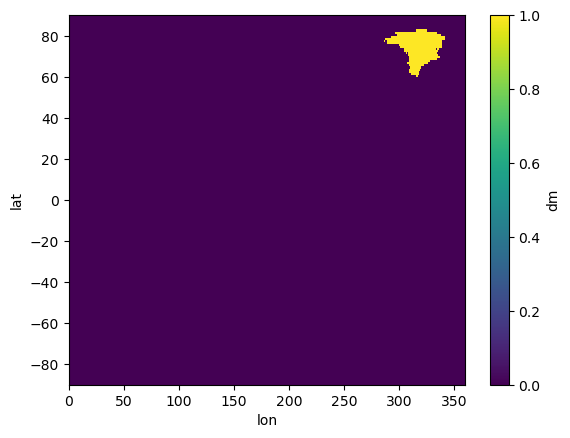

In [11]:
#check the areas before and after regridding
LMAX = 360

# Check if the total addeed mass is equal to the total mass loss of grearctica


# First, compute the area of each cell

# Get the average radius of the eath [cm] using LMAX (same method as in GRD patterns) 
factors = gravtk.units(lmax=LMAX)
rad_e = factors.rad_e/10**5 # Convert to km
rad_e_m = rad_e*1000 #convert to meters

area_da = landsea.copy()

deg2rad = np.pi/180
area_d1 = rad_e_m**2*np.cos(area_da.lat*deg2rad)*deg2rad**2   #calculate for every lat and lon combination the area. actually it depends only on latitude 

area_da.data = area_d1.data[:,np.newaxis]*np.ones(len(area_da.lon))

area_da.name = 'cell area [m**2]'

#this can only be done after running the sea level equation so this needs to be done afterwards 

#oc_vol_change = area_da*rsl_da/100 #assuming rsl is given in cm
#tot_vol_change = oc_vol_change.sum()

#rho = 1000 #kg/m3
#total_kig_added = tot_vol_change*rho  #assuming for now 1000 kg/m3, the same as used in the GRD patterns now

#print('kg added')
#print(total_kig_added.data)

#print(f"🌊 Total added water mass to the ocean:                          {total_kig_added.data:,.15e} kg")


# Check total mass loss between 2002 and now based on gre_y

gresumyear = (gre_y['dm']*gre_y['area']).sum(dim=['x', 'y'], skipna=True)    # gre/y in kg/m^2 per year and area in m2.. 


totalmassgre = (gresumyear.isel(time=-1) - gresumyear.isel(time=0))         #from gt back to kg
#print(f"TOTAL MASS LOSS BETWEEN 2002 AND 2024:{totalmassgre1:.3e} kg")

print(f"🧊 Total mass loss grearctica between 2002 and 2024:            {totalmassgre:.15e} kg")

#now calculate the total removed mass according to the regridded map: 
regriddedchange = area_da * totalgre 
regriddedchange_tot = regriddedchange.sum()
print(f"🏔  Total mass decrease grearctica calculated after regridding:  {regriddedchange_tot:.15e} kg")



#maskje1 = xr.where(np.isnan((Agre_y['dm'].isel(time=-1) - Agre_y['dm'].isel(time=0))), 0, 1)
#maskje1.plot()

areabeforeregridding = (Agre_y['area']*maskje1).sum(dim=['x', 'y'], skipna=True)
#areabeforeregridding = gre_y['area'].sum(dim=['x', 'y'], skipna=True)
print('Total area before regridding')
print(f"{areabeforeregridding.values:.3e}")


#create a mask array which is 1 for all totalgre_withnan values with valid data
#maskje = xr.where(np.isnan(totalgre_withnan), 0, 1)
#maskje.plot()

# this only works because the values in the totalgre are never exactly 0. When this becomes true the code has to be adjusted
maskje = xr.where(
    (np.isnan(totalgre_withnan)) | (totalgre_withnan == 0),
    0,
    1
)
maskje.plot()


areaafterregridding = area_da*maskje
totalareaafter = areaafterregridding.sum()
print('Total area after regridding')
print(f"{totalareaafter.values:.3e}")

areadif = areabeforeregridding - totalareaafter
print('Difference in area in m2')
print(f"{areadif.values:.3e}")



# assume a mass loss of 10000 kg/m2 on average for missing areas
print('missing mass losss in Gt')
print((areadif*10000*10**(-12)).values)


differenceloss = totalmassgre - regriddedchange_tot
print('Difference in mass loss in gt')
print(differenceloss.values*10**(-12))



# now a new reference map can be defined for regridding algorithm ! Adjust that later in the function 



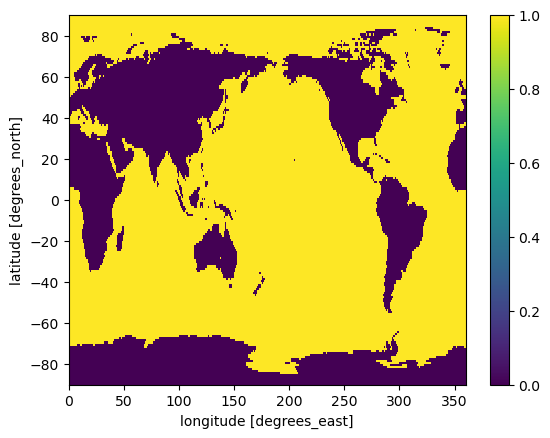

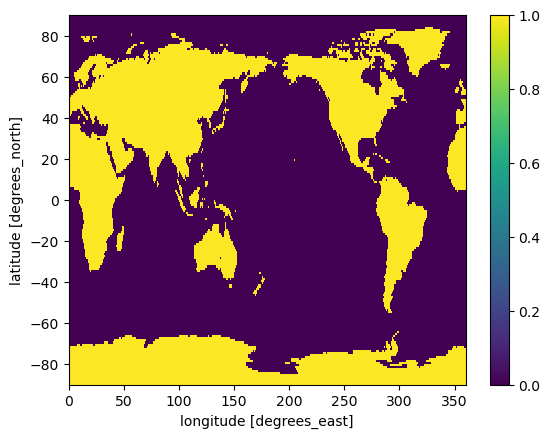

In [12]:
union_mask = xr.where((landsea == 1) | (maskje == 1), 1, 0)
# where landsea is 0 (water) and makje is 1, mass is added at the ocean, which apparently does not work for the sealevelequation. So therefore we take the union to make sure all mass is added on land. 
testmask = xr.where((landsea == 0) | (maskje == 1), 1, 0)  
# the next plot shows there are some areas at grearctica where mass is added at regions defined as sea in the original mask, so therefore the union mask is created. 
testmask.plot()
plt.show()
union_mask.plot()

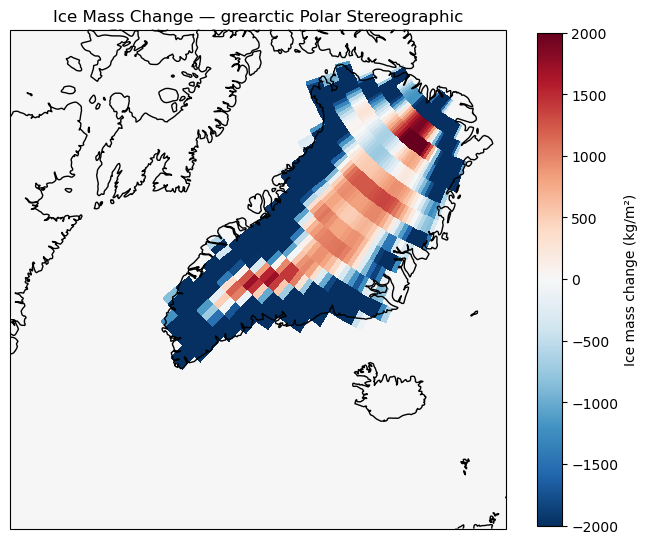

In [13]:

import cartopy.crs as ccrs

# Define the grearctic Polar Stereographic projection (EPSG:3031)
grearctic_crs = ccrs.NorthPolarStereo()

# Create a single plot (not a subplot grid)
plt.figure(figsize=(8, 8))
#ax = plt.axes(projection=grearctic_crs)
ax = plt.axes(projection=grearctic_crs)

# Add context layers
ax.coastlines()#resolution='110m', color='black', linewidth=0.8)
#ax.gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)
#ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())  # view over grearctica
#ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())  # view over grearctica
ax.set_extent([-75, -10, 58, 85], ccrs.PlateCarree())
# Plot the data
mesh = ax.pcolormesh(
    totalgre['lon'], totalgre['lat'], totalgre,
    #landsea['lon'], landsea['lat'], landsea,
    transform=ccrs.PlateCarree(),  # because lon/lat are in degrees (WGS84)
    cmap="RdBu_r",
    vmin=-2000, vmax=2000
)

# Add colorbar
cbar = plt.colorbar(
    mesh, ax=ax, orientation='vertical',
    shrink=0.8, aspect=20, pad=0.05,
    label='Ice mass change (kg/m²)'
)

plt.title("Ice Mass Change — grearctic Polar Stereographic", fontsize=12)
plt.show()


In [14]:
# Calculate the colatitude in radians: 

th = (90 - lat_target)*np.pi/180.0
LMAX = 360
LOVE = gravtk.load_love_numbers(LMAX)
PLM, dPLM = gravtk.plm_holmes(LMAX, np.cos(th))
LOVE0 = (LOVE[0]-LOVE[0], LOVE[1]-LOVE[1], LOVE[2]-LOVE[2])


In [15]:
# Method 2 from notebook ComputeGRD
#tptalgre=dm_diff
#It uses a dinsity of 1 standard but that is not realistic I think??? SOLVE THIS!!
Ylms = gravtk.gen_stokes(totalgre.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE, PLM=PLM)
Ylms_L0 = gravtk.gen_stokes(totalgre.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE0, PLM=PLM)
#Ylms = gravtk.gen_stokes(dm_diff.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE, PLM=PLM)
#Ylms_L0 = gravtk.gen_stokes(dm_diff.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE0, PLM=PLM)



Ylms

print("Ylms.clm shape:", Ylms.clm.shape)
print("lon_target:", len(lon_target))
print("lat_target:", len(lat_target))
print("landsea shape:", landsea.shape)
print('lalal')

Ylms.clm shape: (361, 361)
lon_target: 360
lat_target: 180
landsea shape: (180, 360)
lalal


<xarray.DataArray (lat: 180, lon: 360)> Size: 518kB
array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.255668  , -1.25537505, -1.25276832, ..., -1.24887207,
        -1.25187338, -1.25430545],
       [-0.99862942, -0.97796337, -0.95948536, ..., -1.07050365,
        -1.04526777, -1.02118073],
       [-1.12119601, -1.13870696, -1.1557733 , ..., -1.06657106,
        -1.0850711 , -1.10329828]], shape=(180, 360))
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

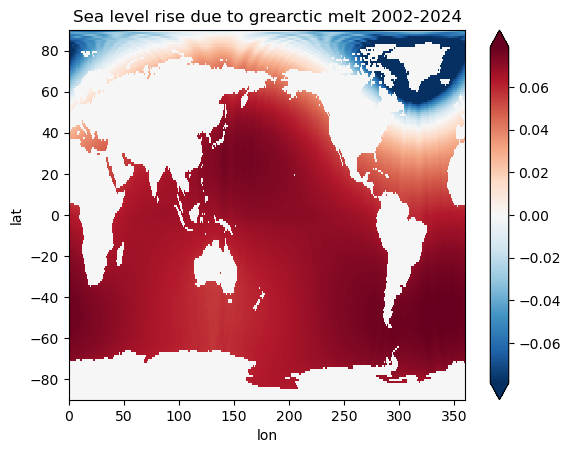

In [16]:
rsl = gravtk.sea_level_equation(Ylms.clm, Ylms.slm, lon_target, lat_target, union_mask.data.T, #landsea.data.T,
    LMAX=LMAX, PLM=PLM, LOVE=LOVE, ITERATIONS=6, POLAR=True)

rsl_da = xr.DataArray(
    data=rsl.T,              # transpose if needed
    dims=["lat", "lon"],     # match array shape
    coords={"lat": lat_target, "lon": lon_target}
)

#rsl_da.plot(robust=True, cmap="RdBu_r")

#rsl_da = xr.DataArray(data=rsl, 
#                       dims=['lon', 'lat'],
#                      coords=['lon': lon_target, 'lat': lat_target])

#rsl_da.T.plot(robust=True)


# Convert longitudes from 0–360 to -180–180
#rsl_da = rsl_da.assign_coords(lon=(((rsl_da.lon + 180) % 360) - 180))

# Sort by longitude so that it plots correctly
#rsl_da = rsl_da.sortby('lon')



# Now plot again
(rsl_da/22).plot(robust=True, cmap="RdBu_r")
plt.title('Sea level rise due to grearctic melt 2002-2024')

rsl_da

🌊 Total added water mass to the ocean:                          4.629816383713531e+15 kg
🧊 Total mass loss grearctica between 2002 and 2024:            -4.629164231601924e+15 kg
🏔  Total mass decrease grearctica calculated after regridding:  -4.629816383713532e+15 kg
Total area before regridding
1.830e+12
Total area after regridding
2.077e+12
Difference in area in m2
-2.474e+11
missing mass losss in Gt
-2473.8542997671975
Difference in mass loss in gt
0.652152111608


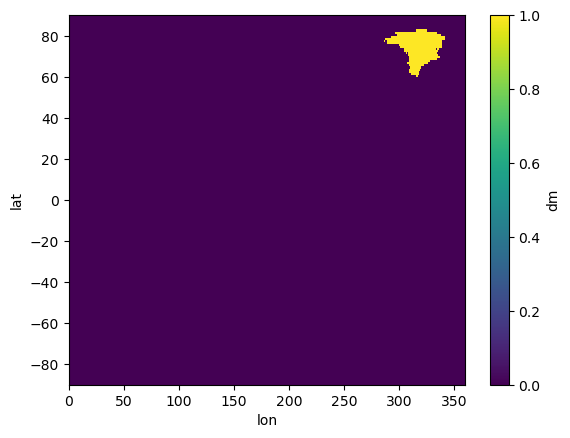

In [17]:
# Check if the total addeed mass is equal to the total mass loss of grearctica


# First, compute the area of each cell

# Get the average radius of the eath [cm] using LMAX (same method as in GRD patterns) 
factors = gravtk.units(lmax=LMAX)
rad_e = factors.rad_e/10**5 # Convert to km
rad_e_m = rad_e*1000 #convert to meters

area_da = landsea.copy()

deg2rad = np.pi/180
area_d1 = rad_e_m**2*np.cos(area_da.lat*deg2rad)*deg2rad**2   #calculate for every lat and lon combination the area. actually it depends only on latitude 

area_da.data = area_d1.data[:,np.newaxis]*np.ones(len(area_da.lon))

area_da.name = 'cell area [m**2]'
#area_da.plot()

# Check the computation of the area is done in compute grd patterns and there it is shown it is similar
#earth_surf_area = 4*np.pi*rad_e**2
#print('Analytical computation')
#print(earth_surf_area)
#print('Sum of grid')
#print(area_da.sum().data)

oc_vol_change = area_da*rsl_da/100 #assuming rsl is given in cm
tot_vol_change = oc_vol_change.sum()

rho = 1000 #kg/m3
total_kig_added = tot_vol_change*rho  #assuming for now 1000 kg/m3, the same as used in the GRD patterns now

#print('kg added')
#print(total_kig_added.data)
print(f"🌊 Total added water mass to the ocean:                          {total_kig_added.data:,.15e} kg")


# Check total mass loss between 2002 and now based on gre_y

gresumyear = (gre_y['dm']*gre_y['area']).sum(dim=['x', 'y'], skipna=True)    # gre/y in kg/m^2 per year and area in m2.. 


totalmassgre = (gresumyear.isel(time=-1) - gresumyear.isel(time=0))         #from gt back to kg
#print(f"TOTAL MASS LOSS BETWEEN 2002 AND 2024:{totalmassgre1:.3e} kg")

print(f"🧊 Total mass loss grearctica between 2002 and 2024:            {totalmassgre:.15e} kg")

#now calculate the total removed mass according to the regridded map: 
regriddedchange = area_da * totalgre 
regriddedchange_tot = regriddedchange.sum()
print(f"🏔  Total mass decrease grearctica calculated after regridding:  {regriddedchange_tot:.15e} kg")



#maskje1 = xr.where(np.isnan((Agre_y['dm'].isel(time=-1) - Agre_y['dm'].isel(time=0))), 0, 1)
#maskje1.plot()

areabeforeregridding = (Agre_y['area']*maskje1).sum(dim=['x', 'y'], skipna=True)
#areabeforeregridding = gre_y['area'].sum(dim=['x', 'y'], skipna=True)
print('Total area before regridding')
print(f"{areabeforeregridding.values:.3e}")


#create a mask array which is 1 for all totalgre_withnan values with valid data
#maskje = xr.where(np.isnan(totalgre_withnan), 0, 1)
#maskje.plot()

# this only works because the values in the totalgre are never exactly 0. When this becomes true the code has to be adjusted
maskje = xr.where(
    (np.isnan(totalgre_withnan)) | (totalgre_withnan == 0),
    0,
    1
)
maskje.plot()


areaafterregridding = area_da*maskje
totalareaafter = areaafterregridding.sum()
print('Total area after regridding')
print(f"{totalareaafter.values:.3e}")

areadif = areabeforeregridding - totalareaafter
print('Difference in area in m2')
print(f"{areadif.values:.3e}")



# assume a mass loss of 10000 kg/m2 on average for missing areas
print('missing mass losss in Gt')
print((areadif*10000*10**(-12)).values)


differenceloss = totalmassgre - regriddedchange_tot
print('Difference in mass loss in gt')
print(differenceloss.values*10**(-12))



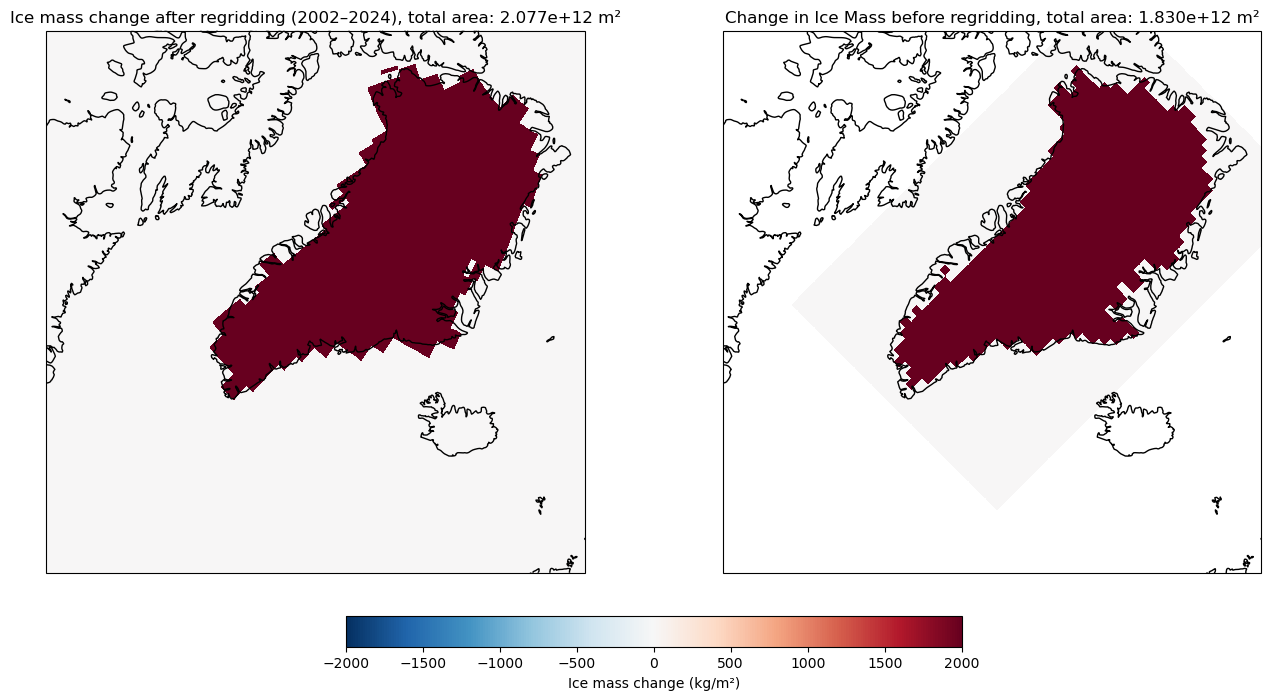

minimum before regridding
-17883.584523809524
miniumum after regridding
-15088.604375717427


In [18]:
import cartopy.crs as ccrs
import numpy as np
import matplotlib.pyplot as plt

grearctic_crs = ccrs.NorthPolarStereo()

diff = gre_y['dm'].isel(time=-1) - gre_y['dm'].isel(time=0)

# Automatically get min and max of data
#vmin = np.nanmin(diff)
#vmax = np.nanmax(diff)

# Create both subplots with the same projection
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 8),
    subplot_kw={'projection': grearctic_crs}
)

# --- Left subplot: grearctic map ---
ax1.coastlines()
#ax1.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
ax1.set_extent([-75, -10, 58, 85], ccrs.PlateCarree())

mesh1 = ax1.pcolormesh(
    totalgre_withnan['lon'], totalgre_withnan['lat'], areaafterregridding,#totalgre_withnan,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=-2000, vmax=2000
)
ax1.set_title(f"Ice mass change after regridding (2002–2024), total area: {totalareaafter:.3e} m²")

# --- Right subplot: grearctic map ---
diff = gre_y['dm'].isel(time=-1) - gre_y['dm'].isel(time=0)

mesh2 = ax2.pcolormesh(
    gre_y['lon'], gre_y['lat'], (Agre_y['area']*maskje1), # diff,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=-2000, vmax=2000
)
ax2.coastlines()
#ax2.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
ax2.set_extent([-75, -10, 58, 85], ccrs.PlateCarree())
ax2.set_title(f"Change in Ice Mass before regridding, total area: {areabeforeregridding:.3e} m²")

# --- Shared colorbar ---
cbar = fig.colorbar(mesh2, ax=[ax1, ax2], orientation='horizontal', fraction=0.05, pad=0.07)
cbar.set_label('Ice mass change (kg/m²)')

plt.show()


print('minimum before regridding')
print(diff.min().values)
print('miniumum after regridding')
print(totalgre.min().values)

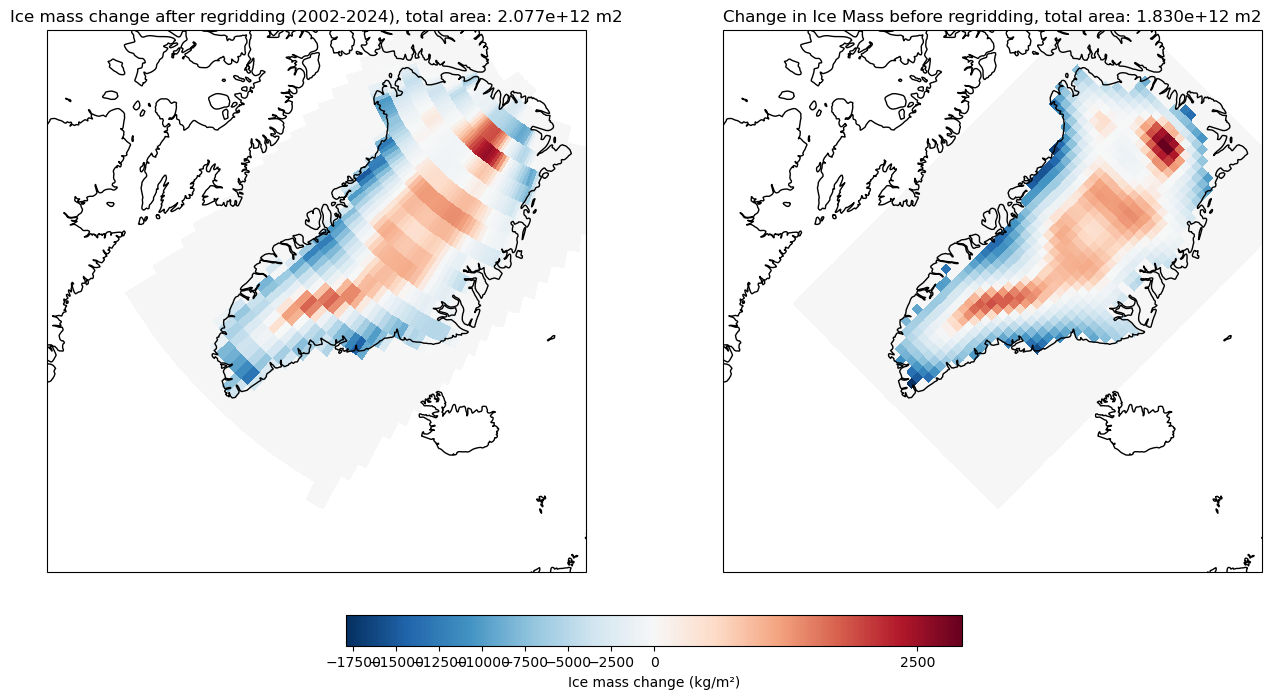

In [19]:
import cartopy.crs as ccrs
import numpy as np
from matplotlib.colors import TwoSlopeNorm

grearctic_crs = ccrs.NorthPolarStereo()


diff = gre_y['dm'].isel(time=-1) - gre_y['dm'].isel(time=0)

# Automatically get min and max of data
vmin = np.nanmin(diff)
vmax = np.nanmax(diff)

# Set midpoint at 0
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)



# Create both subplots with the same projection
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 8),
    subplot_kw={'projection': grearctic_crs}#,
   # constrained_layout=True  # keeps equal scaling
)

# --- Left subplot: grearctic map ---
ax1.coastlines()#resolution='110m', color='black', linewidth=0.8)
#ax1.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
ax1.set_extent([-75, -10, 58, 85], ccrs.PlateCarree())

mesh1 = ax1.pcolormesh(
    totalgre_withnan['lon'], totalgre_withnan['lat'], totalgre_withnan,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r'#, vmin=-2000, vmax=2000
    , norm=norm  #only test this
)
ax1.set_title(f"Ice mass change after regridding (2002-2024), total area: {totalareaafter:.3e} m2")


# --- Right subplot: grearctic map (same projection!) ---
diff = gre_y['dm'].isel(time=-1) - gre_y['dm'].isel(time=0)
mesh2 = ax2.pcolormesh(
    gre_y['lon'], gre_y['lat'], diff,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r'#, vmin=-2000, vmax=2000
    , norm=norm
)
ax2.coastlines()
#ax2.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
ax2.set_extent([-75, -10, 58, 85], ccrs.PlateCarree())
ax2.set_title(f"Change in Ice Mass before regridding, total area: {areabeforeregridding:.3e} m2")

# --- Shared colorbar ---
cbar = fig.colorbar(mesh2, ax=[ax1, ax2], orientation='horizontal', fraction=0.05, pad=0.07)
cbar.set_label('Ice mass change (kg/m²)')

plt.show()


start


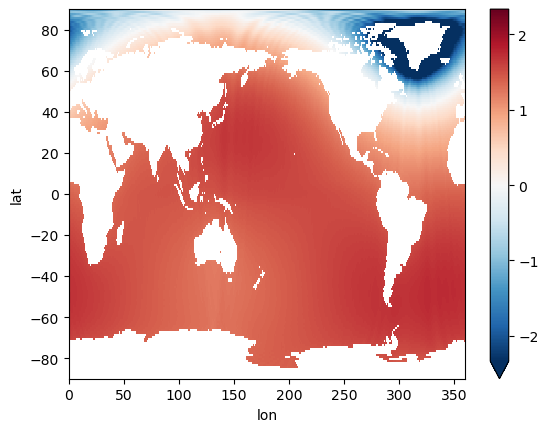

In [20]:
#test with function:
print('start')

function_rsl = ky.sealevelfunctions(totalgre, lon_target, lat_target, union_mask)#landsea)

(function_rsl).plot(robust=True, cmap="RdBu_r")



Jaar
2002
Jaar
2003
Jaar
2004
Jaar
2005
Jaar
2006
Jaar
2007
Jaar
2008
Jaar
2009
Jaar
2010
Jaar
2011
Jaar
2012
Jaar
2013
Jaar
2014
Jaar
2015
Jaar
2016
Jaar
2017
Jaar
2018
Jaar
2019
Jaar
2020
Jaar
2021
Jaar
2022
Jaar
2023
Jaar
2024


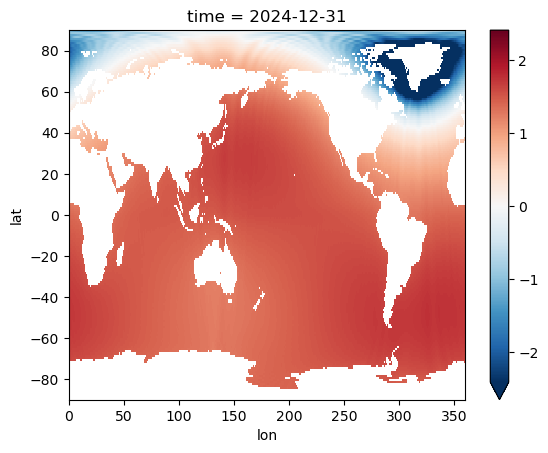

In [21]:
totalgre2 = dm_lonlat_zero.isel(time=-7) - dm_lonlat_zero.isel(time=0) #this is how totalgre is calculated for the last year
grereference = dm_lonlat_zero - dm_lonlat_zero.isel(time=0)


results = []
step=2001
for t in grereference.time:
    step=step+1
    print('Jaar')
    print(step) 
    totalgre_t = grereference.sel(time=t)
    hoi_t = ky.sealevelfunctions(totalgre_t, lon_target, lat_target, landsea)
    results.append(hoi_t)

# Combine all time slices into a single xarray DataArray
hoi_all = xr.concat(results, dim=grereference.time)
hoi_all["time"] = grereference.time



# Plot an example year
hoi_all.isel(time=-1).plot(robust=True, cmap="RdBu_r")

hoi=ky.sealevelfunctions(totalgre2, lon_target, lat_target, union_mask)

#hoi.plot(robust=True, cmap="RdBu_r")



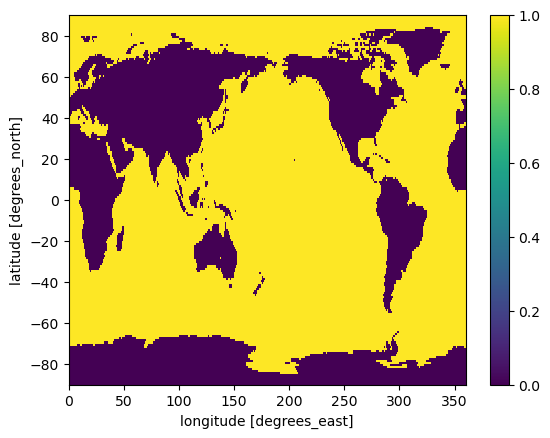

1.0155540053970467


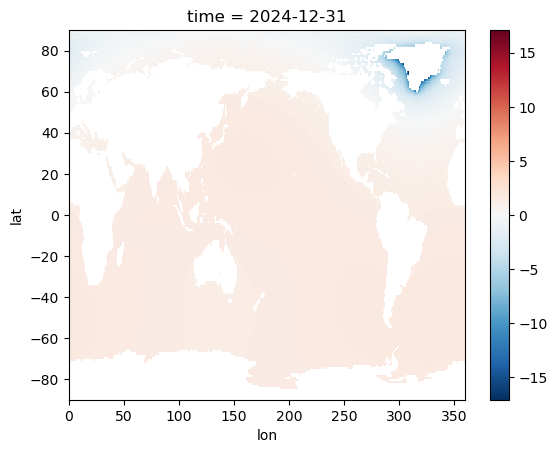

In [22]:

#Compute vmean
seamask = (union_mask == 0)
seamask.plot()
plt.show()
hoi_sea = hoi_all.isel(time=-1).where(seamask) 
hoi_sea.plot()
vmean = np.nanmean(hoi_sea)
print(vmean)



[ 1  3  6  8 11 14 16 19 22]
0
1
2
3
4
5
6
7
8


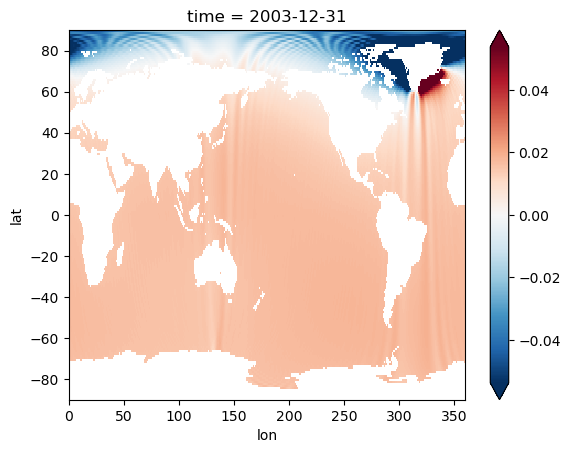

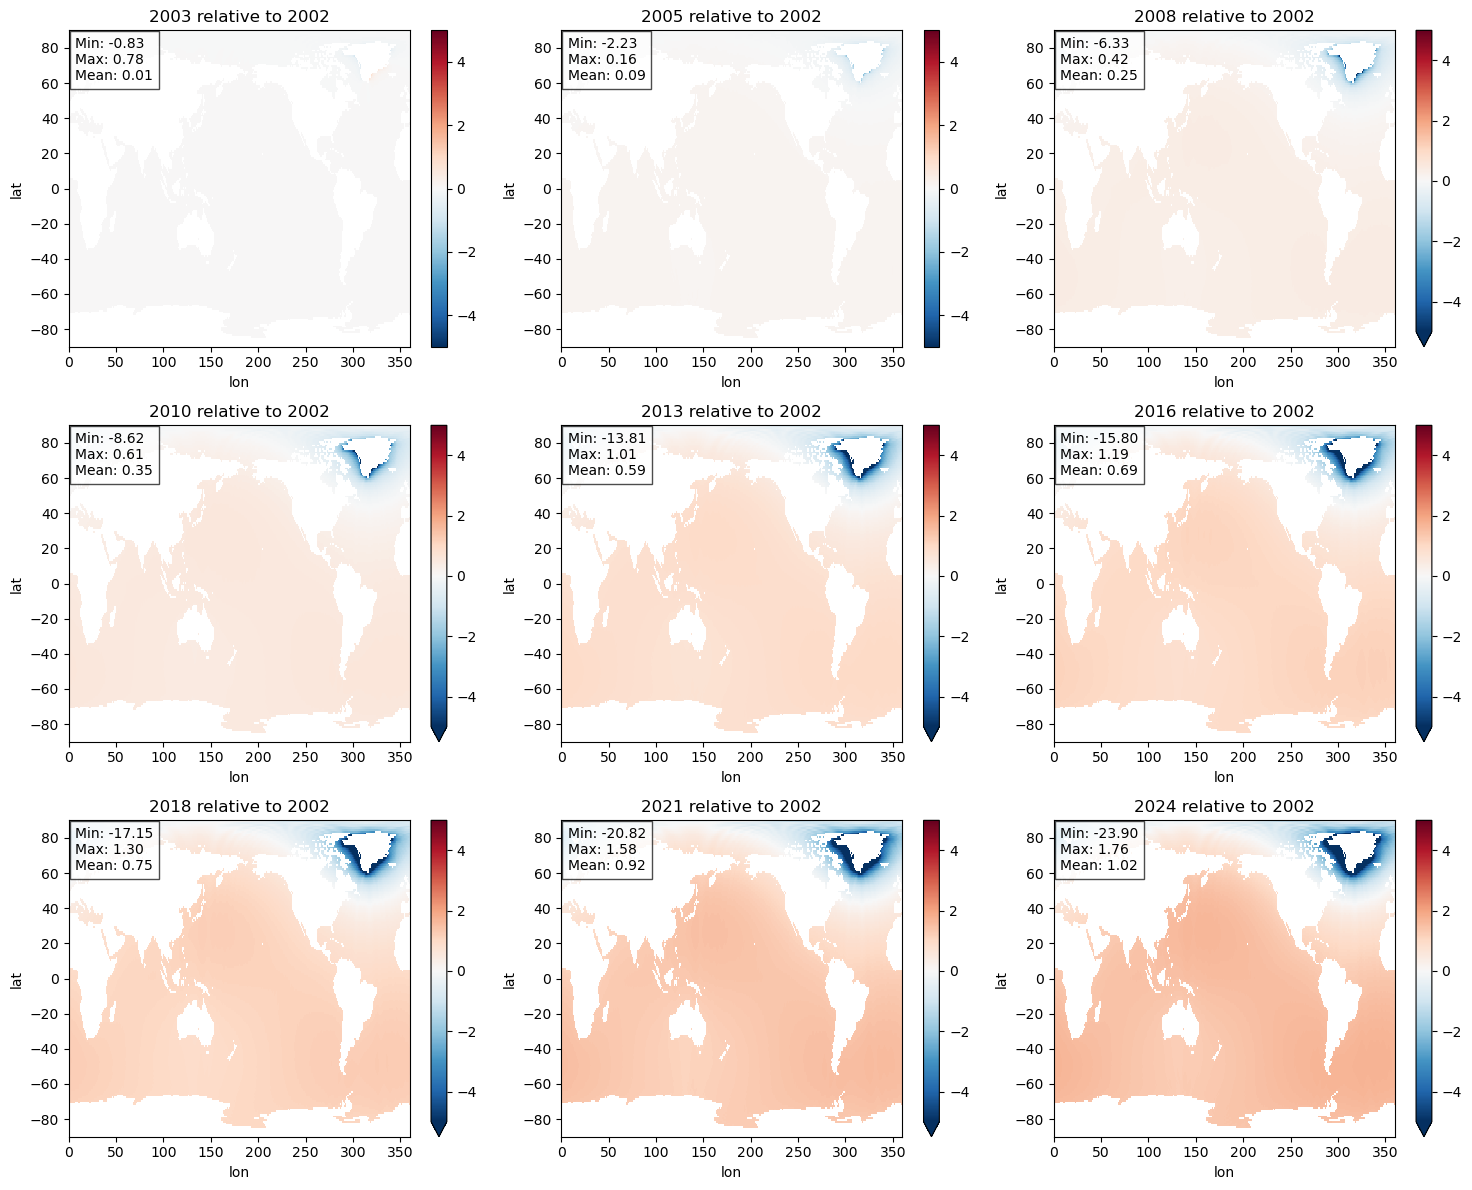

In [23]:
#display(hoi_all)
# Plot an example year
hoi_all.isel(time=1).plot(robust=True, cmap="RdBu_r")

hoi=ky.sealevelfunctions(totalgre2, lon_target, lat_target, landsea)

#hoi.plot(robust=True, cmap="RdBu_r")


# Pick 9 time indices spanning from 0 to 22 (inclusive)
time_indices = np.linspace(1, 22, 9, dtype=int)

print(time_indices)

# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, ax in enumerate(axes):
    
    print(i)
    t = time_indices[i]
    time = 2002 + time_indices[i]
    
    hoi_all.isel(time=t).plot(ax=ax, cmap="RdBu_r", vmin=-5, vmax=5)


    # Compute min, max, mean
    data = hoi_all.isel(time=t).values 
    vmin = np.nanmin(data)
    vmax = np.nanmax(data)


    #Compute vmean
    seamask = (union_mask == 0)
    hoi_sea = hoi_all.isel(time=t).where(seamask) 
    vmean = np.nanmean(hoi_sea)

    # Add a box with the stats
    stats_text = f"Min: {vmin:.2f}\nMax: {vmax:.2f}\nMean: {vmean:.2f}"
    ax.text(
        0.02, 0.98, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', 
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='black')
    )

    
    ax.set_title(f"{time} relative to 2002")

plt.tight_layout()


plt.savefig("C:/Users/kyrab/OneDrive/Afbeeldingen/sealevelrisyears", dpi=300, bbox_inches="tight")

plt.show()


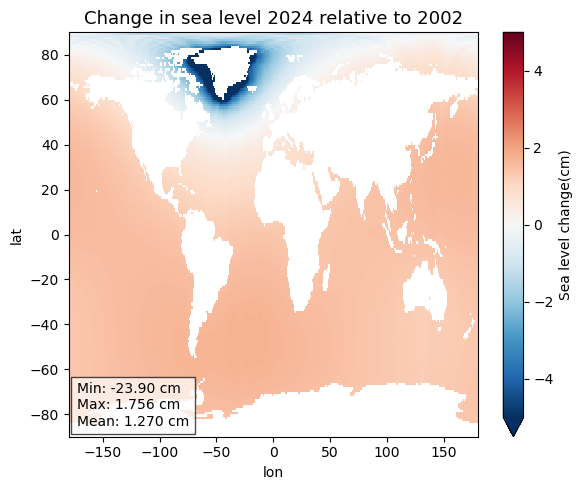

In [36]:
import matplotlib.pyplot as plt
import numpy as np


def rotate_longitude(ds):
    '''Rotate the longitude of an xarray dataset from [0,360] to [-180,180]'''
    
    if 'lon' in ds.dims:
        lon = 'lon'
    elif 'longitude' in ds.dims:
        lon = 'longitude'
    else:
        print('Longitude not found in dimensions')
        
    ds[lon] = np.where(ds[lon]>180, ds[lon]-360, ds[lon])
    ds = ds.reindex({ lon : np.sort(ds[lon])})
    
    return ds




# ---- Select time index for 2024 relative to 2002 ----
# (consistent with your definition: time = 2002 + index)
t = 22
time = 2002 + t

# ---- Select data ----
hoi_2024 = hoi_all.isel(time=t)


# ---- Compute min & max ----
data = hoi_2024.values
vmin = np.nanmin(data)
vmax = np.nanmax(data)

# ---- Compute area-weighted mean over sea only ----
seamask = (union_mask == 0)
hoi_sea = hoi_2024.where(seamask)
weights = area_da.where(seamask)

vmean = (hoi_sea * weights).sum(skipna=True) / weights.sum(skipna=True)
vmean = vmean.values


hoi_2024 = rotate_longitude(hoi_2024)

# ---- Plot single panel ----
fig, ax = plt.subplots(figsize=(6, 5))

hoi_2024.plot(
    ax=ax,
    cmap="RdBu_r",
    vmin=-5,
    vmax=5,
    cbar_kwargs={'label': 'Sea level change(cm)'}
)

# ---- Stats box ----
stats_text = (
    f"Min: {vmin:.2f} cm\n"
    f"Max: {vmax:.3f} cm\n"
    f"Mean: {vmean:.3f} cm"
)
ax.text(
    0.02, 0.135, stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='black')
)

ax.set_title("Change in sea level 2024 relative to 2002", fontsize=13)

plt.tight_layout()
plt.show()


## Create an nc file with yearly increase data

# Compare with frederikse


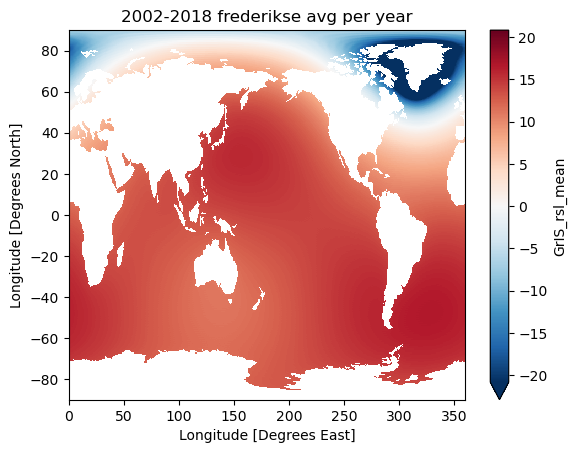

<xarray.DataArray (time: 23, lat: 180, lon: 360)> Size: 12MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [-1.19735795, -1.19833338, -1.19733521, ..., -1.18899952,
         -1.19213836, -1.1950926 ],
        [-0.95983048, -0.93870804, -0.9196598 , ..., -1.03232135,
         -1.00700813, -0.9827153 ],
        [-1.08052807, -1.0975092 , -1.11405787, ..., -1.02755008,
         -1.04549307, -1.06317076]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-1.2590502 , -1.25868599, -1.25601401, ..., -1.25248394,
         -1.25540871, -1.25776325],
        [-1.00125177, -0.98062026, -0.96218611, ..., -1.07308906,
         -1.0478536 , -1.02377907],
        [-1.12473853, -1.14229231, -1.15939922, ..., -1.06997326,
         -1.08852188, -1.10679589]]], shape=(23, 180, 360))
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time     (time) datetime64[ns] 184B 2002-12-31 2003-12-31 ... 2024-12-31

<xarray.DataArray 'GrIS_rsl_mean' ()> Size: 8B
array(-18.26)
<xarray.DataArray ()> Size: 8B
array(-23.90107042)


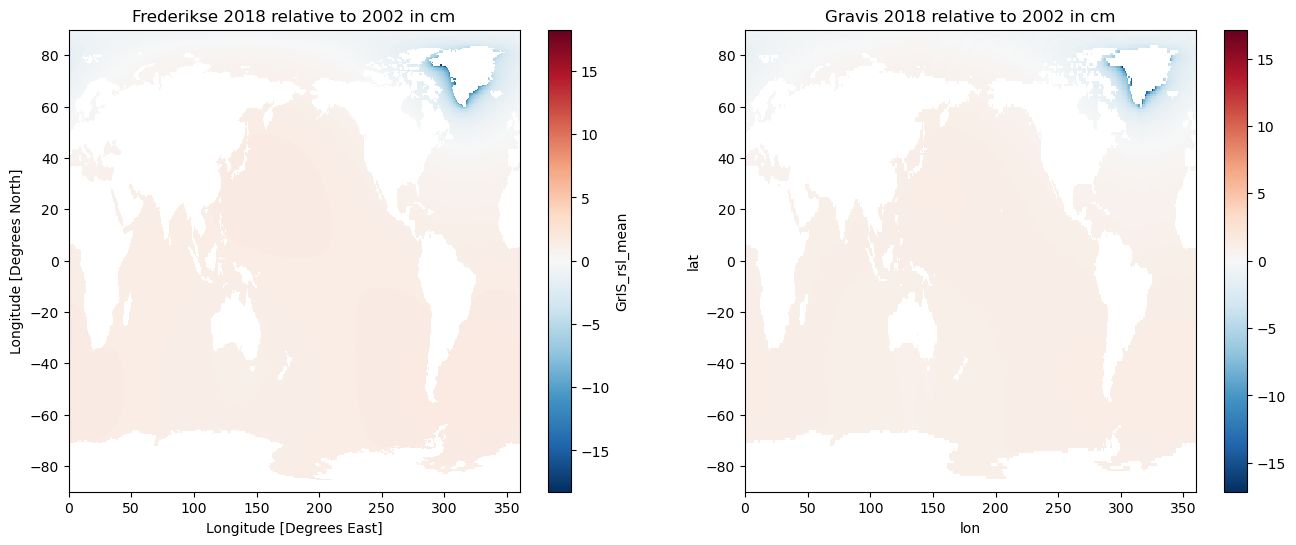

In [25]:
fred_dir = '../data/Frederikse2020/'

gre_ds = xr.open_dataset(f'{fred_dir}GrIS.nc')

((gre_ds['GrIS_rsl_mean'].isel(time=-1)-gre_ds['GrIS_rsl_mean'].isel(time=102))).plot(robust=True, cmap="RdBu_r")


plt.title('2002-2018 frederikse avg per year')
plt.show()

frederikse2018 = ((gre_ds['GrIS_rsl_mean'].sel(time=2018)-gre_ds['GrIS_rsl_mean'].sel(time=2002)))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

(frederikse2018*0.1).plot(ax=ax1, cmap="RdBu_r")#, vmin=-8, vmax=8) # Original is in cm, so now it is in mm
ax1.set_title('Frederikse 2018 relative to 2002 in cm')

hoi_all.isel(time=16).plot(ax=ax2, cmap="RdBu_r")#, vmin=-8, vmax=8) #, vmin=-2000, vmax=2000,
ax2.set_title('Gravis 2018 relative to 2002 in cm')

#gre_ds['AIS_rsl_mean'].isel(time=-1).plot(robust=True, cmap="RdBu_r")
#plt.show()


display(hoi_all)

minimum_fred = frederikse2018.min()*0.1
print(minimum_fred)
minimum_gravis = hoi_all.min()
print(minimum_gravis)



In [25]:
#Create same kind of dataset: 
print('hoi')

hoi


# Now save the data in a nc file 
Then i can use it in the budget and select an area 

In [26]:
# check layout of frederikse: 
display(gre_ds)
#display(hoi_all)


<xarray.Dataset> Size: 987MB
Dimensions:         (time: 119, lat: 360, lon: 720)
Coordinates:
  * lon             (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.8 359.2 359.8
  * lat             (lat) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * time            (time) int16 238B 1900 1901 1902 1903 ... 2016 2017 2018
Data variables:
    GrIS_rsl_mean   (time, lat, lon) float64 247MB ...
    GrIS_rsl_sterr  (time, lat, lon) float64 247MB ...
    GrIS_rad_mean   (time, lat, lon) float64 247MB ...
    GrIS_rad_sterr  (time, lat, lon) float64 247MB ...
Attributes:
    copyright:  This work is licensed under the Creative Commons Attribution-...

In [27]:
# create a nc file with the same format as the data from frederikse to be able to use it easily in the budget 

# translate the datetime of hoi to an array with years: 

gre_costg = xr.Dataset(
    coords = {
        'lon': hoi_all['lon'].values, 
        'lat': hoi_all['lat'].values,
        'time': hoi_all['time'].dt.year.values
    },
    data_vars = {
        'AIS_Gravis': (['time', 'lat', 'lon'], hoi_all.values)
    },
    attrs = {
        'Info': 'Based on Gravis data and created using the gravity toolkit',
    }
)

gre_costg['lon'].attrs = {'long_name': 'Longitude', 'units': 'Degrees East'}
gre_costg['lat'].attrs = {'long_name': 'Latitude', 'units': 'Degrees North'}
gre_costg['time'].attrs = {'long_name': 'time (yearly average)', 'standard_name': 'time',  'units': 'years', 'axis': 'T'}


display(gre_costg) 

<xarray.Dataset> Size: 12MB
Dimensions:     (time: 23, lat: 180, lon: 360)
Coordinates:
  * lon         (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * time        (time) int64 184B 2002 2003 2004 2005 ... 2021 2022 2023 2024
Data variables:
    AIS_Gravis  (time, lat, lon) float64 12MB 0.0 0.0 0.0 ... -1.089 -1.107
Attributes:
    Info:     Based on Gravis data and created using the gravity toolkit

In [28]:
import os

print(output_path2)
print(os.path.exists(output_path2))

gre_costg.to_netcdf(output_path2 + 'Gravis_gre.nc')

../outputs/Gravis_Antarctica/
True
